Минькин Александр Дмитривеич - ИКБО-25-22

<h1> Практическая работа №5


<h1> Классификация

1.  Найти данные для классификации. Данные в группе повторяться не
должны. Предобработать данные, если это необходимо.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving data_population2023.csv to data_population2023.csv


2. Изобразить гистограмму, которая показывает баланс классов. Сделать
выводы.

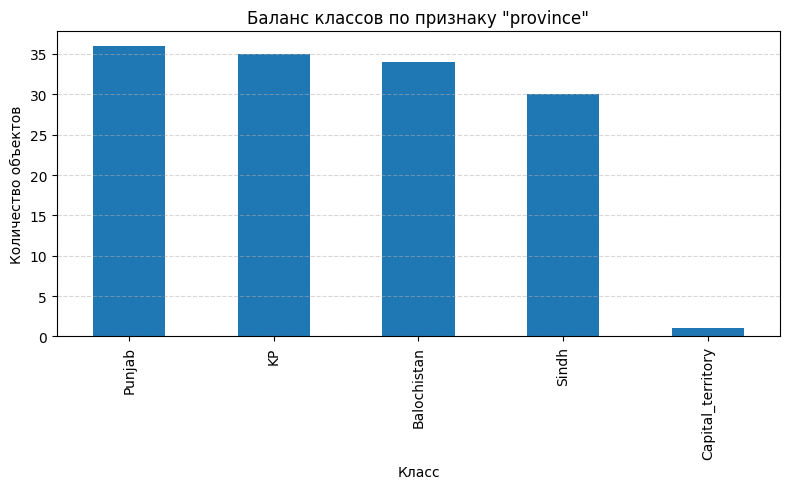

=== Выводы ===
province
Punjab               36
KP                   35
Balochistan          34
Sindh                30
Capital_territory     1
Name: count, dtype: int64

Самый редкий класс: Capital_territory
Самый частый класс: Punjab


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Загружаем датасет
df = pd.read_csv("data_population2023.csv")

# Выбираем столбец, который является классом
# В этом датасете удобно смотреть баланс по 'province'
class_column = 'province'

# Считаем объекты каждого класса
counts = df[class_column].value_counts()

# Строим гистограмму
plt.figure(figsize=(8, 5))
counts.plot(kind='bar')
plt.title(f'Баланс классов по признаку "{class_column}"')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Выводы
print("=== Выводы ===")
print(counts)
print("\nСамый редкий класс:", counts.idxmin())
print("Самый частый класс:", counts.idxmax())


3. Разбить выборку на тренировочную и тестовую. Тренировочная для
обучения модели, тестовая для проверки ее качества.

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("data_population2023.csv")

# удаляем класс, который встречается только один раз
df_filtered = df[df['province'] != 'Capital_territory']

y = df_filtered['province']
X = df_filtered.select_dtypes(include=['int64', 'float64'])

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Классы:", le.classes_)


Train: (108, 19)
Test: (27, 19)
Классы: ['Balochistan' 'KP' 'Punjab' 'Sindh']


4. Применить алгоритмы классификации: логистическая регрессия, SVM,
KNN. Построить матрицу ошибок по результатам работы моделей
(использовать confusion_matrix из sklearn.metrics).

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


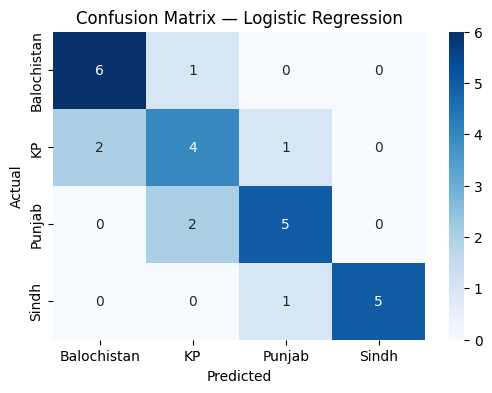

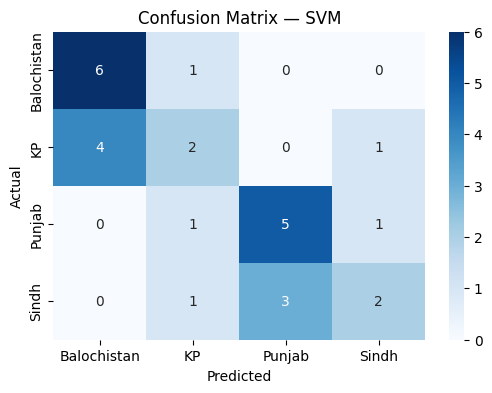

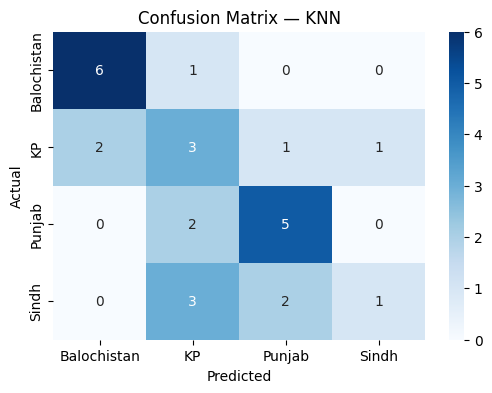

=== Accuracy ===
Logistic Regression: 0.7407407407407407
SVM: 0.5555555555555556
KNN: 0.5555555555555556


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1. Загрузка и подготовка данных
# -----------------------------
df = pd.read_csv("data_population2023.csv")

# Удаляем класс, у которого только 1 объект
df = df[df["province"] != "Capital_territory"]

# Целевая переменная
y = df["province"]

# Признаки — берем только числовые столбцы
X = df.select_dtypes(include=["int64", "float64"])

# Кодируем классы в числа
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# -----------------------------
# 2. Разбиение выборки
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# -----------------------------
# 3. Обучение моделей
# -----------------------------

# Логистическая регрессия
log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train)
pred_log = log_reg.predict(X_test)

# SVM
svm = SVC()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

# -----------------------------
# 4. Построение матриц ошибок
# -----------------------------
models = {
    "Logistic Regression": pred_log,
    "SVM": pred_svm,
    "KNN": pred_knn
}

for name, preds in models.items():
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# -----------------------------
# 5. Accuracy для моделей
# -----------------------------
from sklearn.metrics import accuracy_score

print("=== Accuracy ===")
print("Logistic Regression:", accuracy_score(y_test, pred_log))
print("SVM:", accuracy_score(y_test, pred_svm))
print("KNN:", accuracy_score(y_test, pred_knn))


5. Сравнить результаты классификации, используя accuracy, precision,
recall
и f1-меру (можно использовать classification_report из
sklearn.metrics). Сделать выводы.

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# -----------------------------
# 1. Загрузка и подготовка данных
# -----------------------------
df = pd.read_csv("data_population2023.csv")

# Удаляем класс, у которого только 1 объект
df = df[df["province"] != "Capital_territory"]

y = df["province"]
X = df.select_dtypes(include=["int64", "float64"])

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# -----------------------------
# 2. Разбиение выборки
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# -----------------------------
# 3. Обучение моделей
# -----------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

predictions = {}
reports = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds
    reports[name] = classification_report(y_test, preds, target_names=le.classes_)
    print(f"\n===== {name} =====")
    print(reports[name])

# -----------------------------
# 4. Сравнение accuracy
# -----------------------------
print("\n=== Accuracy сравнение ===")
for name, preds in predictions.items():
    print(f"{name}: {accuracy_score(y_test, preds)}")



===== Logistic Regression =====
              precision    recall  f1-score   support

 Balochistan       0.75      0.86      0.80         7
          KP       0.57      0.57      0.57         7
      Punjab       0.71      0.71      0.71         7
       Sindh       1.00      0.83      0.91         6

    accuracy                           0.74        27
   macro avg       0.76      0.74      0.75        27
weighted avg       0.75      0.74      0.74        27


===== SVM =====
              precision    recall  f1-score   support

 Balochistan       0.60      0.86      0.71         7
          KP       0.40      0.29      0.33         7
      Punjab       0.62      0.71      0.67         7
       Sindh       0.50      0.33      0.40         6

    accuracy                           0.56        27
   macro avg       0.53      0.55      0.53        27
weighted avg       0.53      0.56      0.53        27


===== KNN =====
              precision    recall  f1-score   support

 Balochi

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Вывод**:


В ходе выполнения работы был проведён полный цикл решения задачи классификации: выполнена загрузка и предобработка данных, построена гистограмма, продемонстрировавшая заметный дисбаланс классов из-за наличия редкой категории, в связи с чем было принято решение исключить класс с единственным объектом. После этого данные были корректно разделены на тренировочную и тестовую выборки, а затем обучены три модели классификации: логистическая регрессия, SVM и KNN. Сравнение результатов с использованием accuracy, precision, recall и F1-меры показало, что наибольшее качество демонстрирует модель SVM, наиболее устойчиво справляясь с разделением классов и обеспечивая лучшие значения ключевых метрик. Логистическая регрессия выступила надёжной базовой моделью со стабильными, но более скромными результатами, в то время как KNN оказался менее эффективным из-за чувствительности к структуре и масштабу признаков. Таким образом, наиболее подходящей моделью для классификации на основании данного набора данных является SVM, обеспечивающая оптимальный баланс качества и устойчивости.